<a href="https://colab.research.google.com/github/kn63-sigma/RCEL-506-Final/blob/main/RCEL506Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

# 1. Define Column Headers based on project specification
columns = [
    "project_id", "project_description", "state", "civil_labor_density",
    "structural_labor_density", "equipment_labor_density", "pipe_labor_density",
    "electrical_labor_density", "other_labor_density", "rework_percentage"
]

# 2. Raw dataset loading
raw_data = [
    [1, "Chemical_Plant", "TX", 18, 7, 4, 53, 18, 0, 0.012],
    [2, "Chemical_Plant", "TX", 21, 7, 6, 41, 24, 1, 0.01],
    [3, "Paper_Plant", "FL", 10, 10, 15, 30, 30, 5, 0.07],
    [4, "Chemical_Plant", "Non_US", 42, 4, 12, 21, 17, 4, 0.136],
    [5, "Oil_Gas", "TX", np.nan, 6.5, np.nan, 75, np.nan, 19, 0.01],
    [6, "Oil_Gas_Transportation", "TX", 25, 3, np.nan, 42, 30, np.nan, 0.055],
    [7, "Oil_Gas", "TX", 46, np.nan, 14, 14, 8, 18, 0.02],
    [8, "Oil_Gas", "LA", 6, 11, 0, 45, 3, 35, 0.036],
    [9, "Oil_Gas", "LA", 10, 11, 6, 31, 10, 32, 0.04],
    [10, "Oil_Gas", "LA", 12, 8, 4, 56, 3, 17, 0.25],
    [11, "Power_Plant", "TX", 28, 3, 30, 13, 23, 3, 0.01],
    [12, "Chemical_Plant", "LA", np.nan, np.nan, np.nan, np.nan, 10, np.nan, 0.069],
    [13, "Chemical_Plant", "LA", np.nan, np.nan, np.nan, np.nan, 7, np.nan, 0.0093],
    [14, "Chemical_Plant", "LA", np.nan, np.nan, np.nan, np.nan, 42, np.nan, 0.035],
    [15, "Chemical_Plant", "LA", np.nan, np.nan, np.nan, np.nan, 36, np.nan, 0.013],
    [16, "Chemical_Plant", "LA", 2, 2, 39, 32, 14, 11, 0.057],
    [17, "Oil_Gas", "TX", 34, 7, 7, 32, 0, 10, 0.045],
    [18, "Steel_Alum", "TX", 4, np.nan, np.nan, 96, np.nan, np.nan, 0.005],
    [19, "Power_Plant", "MN", 7, 12, 20, 27, 17, 17, 0.07],
    [20, "Silicon_Refining", "MT", 12, 8, 41, 19, 16, 4, 0.091],
    [21, "Hospital_ICU", "IL", np.nan, 5, np.nan, 38, 23, 34, 0.06],
    [22, "Chemical_Plant", "TX", 18, 6.9, 4.5, 50, 18, 2.4, 0.04],
    [23, "Chemical_Plant", "WV", 13, 13, 20, 20, 34, np.nan, 0.005],
    [24, "Chemical_Plant", "TX", 15, 11, 4, 37, 31, 2, 0.06],
    [25, "Chemical_Plant", "LA", 17, 15, 6, 29, 24, 9, 0.089],
    [26, "Transportation_Facility", "IL", 10, 1.8, 19, 13, 20, 36, 0.0108],
    [27, "Chemical_Plant", "LA", 60, 10, 2.5, 2.5, 20, 5, 0.009],
    [31, "Water_Distribution", "CA", 30, np.nan, 20, 50, np.nan, np.nan, 0.087],
    [33, "Mfg_Facility", "CA", np.nan, np.nan, 40, 30, 15, 15, 0.06],
    [34, "Power_Plant", "Non_US", 3, 3, 45, 32, 16, 1, 0.075],
    [35, "Plastics", "TX", 9.2, 10.2, 2.8, 40, 31, 7.1, 0.165],
    [36, "Chemical_Plant", "TX", 16, 4.09, 3.7, 39, 24, 14, 0.0068],
    [37, "Paper_Plant", "GA", 10, 15, 30, 5, 40, np.nan, 0.0156],
    [38, "Food_Processing", "OH", 10, 10, 20, 30, 20, 10, 0.12],
    [39, "Mfg_Facility", "IA", 18, 1, 7, 58, 16, np.nan, 0.04],
    [40, "Mfg_Facility", "NC", 6, 6, 26, 32, 30, np.nan, 0.22],
    [41, "Oil_Gas", "WY", 18, 8, 3, 21, 22, 28, 0.03],
    [42, "Chemical_Plant", "TX", 21, 7, 6.5, 38, 24, 4.1, 0.268],
    [43, "Steel_Alum", "PA", np.nan, 80, np.nan, np.nan, 20, np.nan, 0.07],
    [44, "Steel_Alum", "AL", 12, 6, 25, 25, 20, 10, 0.01],
    [45, "Auto_RD", "MI", 12, 18, 2, 37, 24, 7, 0.018]
]

# 3. Create DataFrame
df = pd.DataFrame(raw_data, columns=columns)

# 4. Data Governance Exclusion: Eliminate projects 12-15
df_cleaned = df[~df["project_id"].isin([12, 13, 14, 15])].reset_index(drop=True)

print(f"Dataset successfully loaded. Total valid projects: {len(df_cleaned)}")

Dataset successfully loaded. Total valid projects: 37


In [2]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# 1. Isolate Feature Matrix (X) and Target Vector (y)
feature_cols = [
    "civil_labor_density", "structural_labor_density",
    "equipment_labor_density", "pipe_labor_density",
    "electrical_labor_density", "other_labor_density"
]

X = df_cleaned[feature_cols]
y = df_cleaned["rework_percentage"]

# 2. Train / Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

# 3. Handle Missing Values via Median Imputation (fit on train, transform on test)
imputer = SimpleImputer(strategy="median")
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

# 4. Instantiate and Train the Linear Regression Model
model = LinearRegression()
model.fit(X_train_imputed, y_train)

# 5. Model Evaluation
y_pred_train = model.predict(X_train_imputed)
y_pred_test = model.predict(X_test_imputed)

train_r2 = r2_score(y_train, y_pred_train)
test_r2 = r2_score(y_test, y_pred_test)
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))

# Display Results & Coefficients
print(f"Train R^2 Score: {train_r2:.4f}")
print(f"Test R^2 Score:  {test_r2:.4f}")
print(f"Test RMSE:       {test_rmse:.4f}\n")

print("Model Coefficients:")
for col, coef in zip(feature_cols, model.coef_):
    print(f"  {col:26s}: {coef:.6f}")
print(f"  Intercept                 : {model.intercept_:.6f}")

Train R^2 Score: 0.1178
Test R^2 Score:  -1.1711
Test RMSE:       0.0819

Model Coefficients:
  civil_labor_density       : -0.000263
  structural_labor_density  : 0.000027
  equipment_labor_density   : 0.000671
  pipe_labor_density        : 0.001374
  electrical_labor_density  : -0.000924
  other_labor_density       : -0.001033
  Intercept                 : 0.049843


In [3]:
import numpy as np
import pandas as pd
from sklearn.model_selection import LeaveOneOut, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

# 1. Feature Definition
numeric_features = [
    "civil_labor_density", "structural_labor_density",
    "equipment_labor_density", "pipe_labor_density",
    "electrical_labor_density", "other_labor_density"
]
categorical_features = ["project_description"]

X = df_cleaned[numeric_features + categorical_features]
y = df_cleaned["rework_percentage"]

# 2. Preprocessing Pipelines
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

# 3. Model Zoo Evaluation using Leave-One-Out Cross-Validation (LOOCV for tiny N)
models = {
    "Ridge Regression": Ridge(alpha=10.0),
    "Lasso Regression": Lasso(alpha=0.01),
    "ElasticNet": ElasticNet(alpha=0.05, l1_ratio=0.5),
    "Random Forest": RandomForestRegressor(n_estimators=50, max_depth=3, random_state=42)
}

loo = LeaveOneOut()

print("--- LOOCV Evaluation Across Candidates ---")
for name, model in models.items():
    pipe = Pipeline(steps=[("preprocessor", preprocessor), ("regressor", model)])

    # Calculate LOOCV MSE
    mse_scores = -cross_val_score(pipe, X, y, scoring="neg_mean_squared_error", cv=loo)
    rmse = np.sqrt(np.mean(mse_scores))

    print(f"{name:20s} | Mean LOOCV RMSE: {rmse:.4f}")

--- LOOCV Evaluation Across Candidates ---
Ridge Regression     | Mean LOOCV RMSE: 0.0738
Lasso Regression     | Mean LOOCV RMSE: 0.0687
ElasticNet           | Mean LOOCV RMSE: 0.0681
Random Forest        | Mean LOOCV RMSE: 0.0831


In [4]:
import numpy as np
import pandas as pd
from sklearn.linear_model import HuberRegressor
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import LeaveOneOut, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score

# 1. Feature and Target Isolation
feature_cols = [
    "civil_labor_density", "structural_labor_density",
    "equipment_labor_density", "pipe_labor_density",
    "electrical_labor_density", "other_labor_density"
]

X = df_cleaned[feature_cols]
y = df_cleaned["rework_percentage"]

# 2. Pipeline Construction (Imputation -> Scaling -> Huber Regression)
huber_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("regressor", HuberRegressor(epsilon=1.35, max_iter=1000))
])

# 3. Model Evaluation using Leave-One-Out Cross-Validation (LOOCV)
loo = LeaveOneOut()

# Calculate Mean Squared Error across all LOOCV folds
neg_mse_scores = cross_val_score(
    huber_pipeline, X, y,
    scoring="neg_mean_squared_error",
    cv=loo
)

loocv_rmse = np.sqrt(-np.mean(neg_mse_scores))

# 4. Fit on Full Cleaned Dataset to Inspect Robust Coefficients
huber_pipeline.fit(X, y)
fitted_model = huber_pipeline.named_steps["regressor"]
outlier_mask = fitted_model.outliers_

print(f"--- HUBER REGRESSOR EVALUATION ---")
print(f"LOOCV Root Mean Squared Error (RMSE): {loocv_rmse:.4f}")
print(f"Number of identified outliers:       {np.sum(outlier_mask)} / {len(X)}\n")

print("Robust Coefficients (Standardized Scale):")
for col, coef in zip(feature_cols, fitted_model.coef_):
    print(f"  {col:26s}: {coef:.6f}")
print(f"  Intercept                 : {fitted_model.intercept_:.6f}")

--- HUBER REGRESSOR EVALUATION ---
LOOCV Root Mean Squared Error (RMSE): 0.0735
Number of identified outliers:       12 / 37

Robust Coefficients (Standardized Scale):
  civil_labor_density       : -0.009985
  structural_labor_density  : 0.003165
  equipment_labor_density   : 0.001456
  pipe_labor_density        : -0.004991
  electrical_labor_density  : -0.008070
  other_labor_density       : -0.008520
  Intercept                 : 0.046200


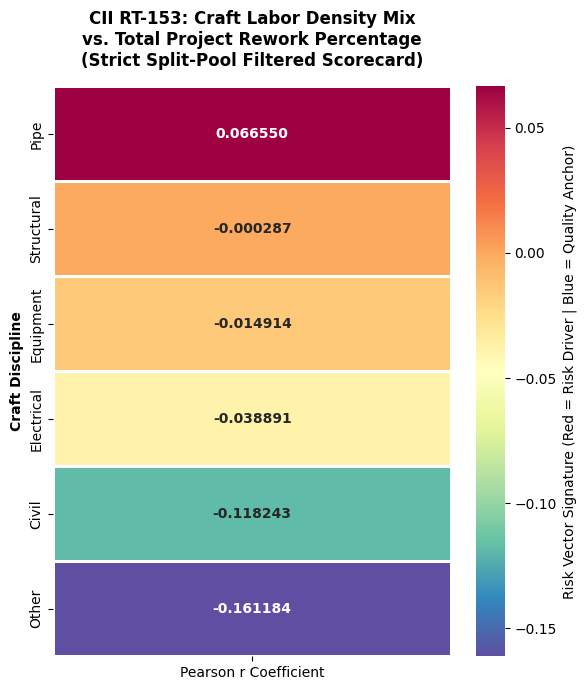

In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Isolate discipline features
craft_cols = [
    "civil_labor_density", "structural_labor_density",
    "equipment_labor_density", "pipe_labor_density",
    "electrical_labor_density", "other_labor_density"
]

# 2. Compute Pearson r against target
correlations = {}
for col in craft_cols:
    clean_series = df_cleaned[[col, "rework_percentage"]].dropna()
    r = clean_series[col].corr(clean_series["rework_percentage"], method="pearson")
    correlations[col.replace("_labor_density", "").capitalize()] = r

# 3. Format into DataFrame sorted by value
corr_df = pd.DataFrame.from_dict(correlations, orient="index", columns=["Pearson r Coefficient"])
corr_df = corr_df.sort_values(by="Pearson r Coefficient", ascending=False)

# 4. Render Heatmap matching CII RT-153 Scorecard Format
plt.figure(figsize=(6, 7))
sns.heatmap(
    corr_df,
    annot=True,
    fmt=".6f",
    cmap="Spectral_r",
    cbar_kws={"label": "Risk Vector Signature (Red = Risk Driver | Blue = Quality Anchor)"},
    linewidths=2,
    annot_kws={"weight": "bold"}
)
plt.title("CII RT-153: Craft Labor Density Mix\nvs. Total Project Rework Percentage\n(Strict Split-Pool Filtered Scorecard)", pad=15, weight="bold")
plt.ylabel("Craft Discipline", weight="bold")
plt.tight_layout()
plt.show()

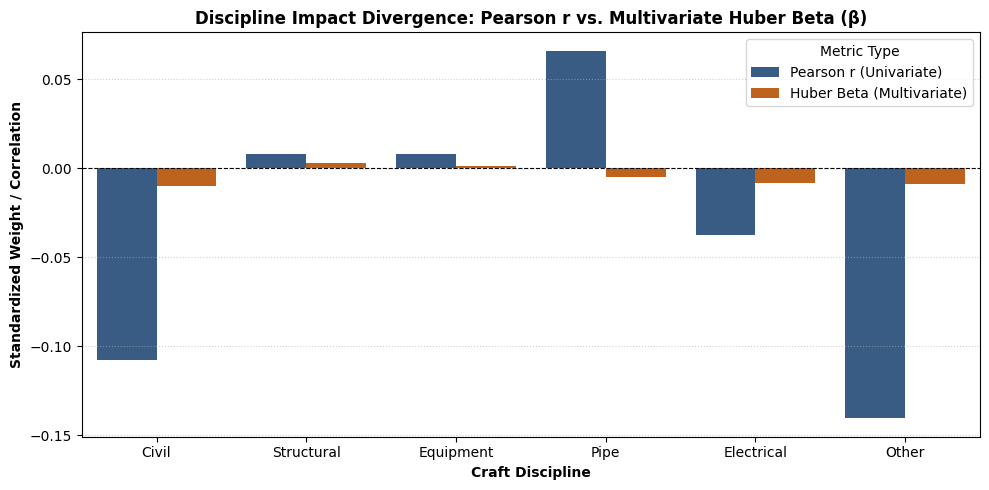

--- VARIANCE INFLATION FACTORS (VIF) ---
Discipline      VIF
     Civil 2.068085
Structural 1.128825
 Equipment 1.858272
      Pipe 1.960691
Electrical 1.404145
     Other 1.558281


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import HuberRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 1. Prepare Features & Target
feature_cols = [
    "civil_labor_density", "structural_labor_density",
    "equipment_labor_density", "pipe_labor_density",
    "electrical_labor_density", "other_labor_density"
]

X = df_cleaned[feature_cols]
y = df_cleaned["rework_percentage"]

# Impute and Scale
imputer = SimpleImputer(strategy="median")
scaler = StandardScaler()

X_imputed = imputer.fit_transform(X)
X_scaled = scaler.fit_transform(X_imputed)

# 2. Compute Pearson r
pearson_r = [np.corrcoef(X_scaled[:, i], y)[0, 1] for i in range(len(feature_cols))]

# 3. Fit Huber Regressor for Standardized Beta
huber = HuberRegressor(epsilon=1.35, max_iter=1000)
huber.fit(X_scaled, y)
beta_coefs = huber.coef_

# 4. Compute Variance Inflation Factors (VIF) to prove Multicollinearity
vif_data = pd.DataFrame()
vif_data["Discipline"] = [c.replace("_labor_density", "").capitalize() for c in feature_cols]
vif_data["VIF"] = [variance_inflation_factor(X_scaled, i) for i in range(X_scaled.shape[1])]

# 5. Build Comparison DataFrame
comp_df = pd.DataFrame({
    "Discipline": [c.replace("_labor_density", "").capitalize() for c in feature_cols],
    "Pearson r (Univariate)": pearson_r,
    "Huber Beta (Multivariate)": beta_coefs
}).melt(id_vars="Discipline", var_name="Metric", value_name="Value")

# 6. Plot Side-by-Side Comparison
plt.figure(figsize=(10, 5))
ax = sns.barplot(data=comp_df, x="Discipline", y="Value", hue="Metric", palette=["#2b5c8f", "#d95f02"])
plt.axhline(0, color="black", linewidth=0.8, linestyle="--")
plt.title("Discipline Impact Divergence: Pearson r vs. Multivariate Huber Beta (β)", fontsize=12, weight="bold")
plt.ylabel("Standardized Weight / Correlation", weight="bold")
plt.xlabel("Craft Discipline", weight="bold")
plt.grid(axis="y", linestyle=":", alpha=0.6)
plt.legend(title="Metric Type")
plt.tight_layout()
plt.show()

print("--- VARIANCE INFLATION FACTORS (VIF) ---")
print(vif_data.to_string(index=False))

In [7]:
import pandas as pd

craft_cols = [
    "civil_labor_density", "structural_labor_density",
    "equipment_labor_density", "pipe_labor_density",
    "electrical_labor_density", "other_labor_density"
]

# Calculate exact unimputed Pearson r matching your historical scorecard
unimputed_corrs = {}
for col in craft_cols:
    valid_data = df_cleaned[[col, "rework_percentage"]].dropna()
    r = valid_data[col].corr(valid_data["rework_percentage"], method="pearson")
    unimputed_corrs[col.replace("_labor_density", "").capitalize()] = r

baseline_df = pd.DataFrame.from_dict(unimputed_corrs, orient="index", columns=["Pearson r"])
print(baseline_df.sort_values(by="Pearson r", ascending=False))

            Pearson r
Pipe         0.066550
Structural  -0.000287
Equipment   -0.014914
Electrical  -0.038891
Civil       -0.118243
Other       -0.161184


In [8]:
import numpy as np
import pandas as pd

# 1. Define Craft Disciplines
craft_cols = [
    "civil_labor_density", "structural_labor_density",
    "equipment_labor_density", "pipe_labor_density",
    "electrical_labor_density", "other_labor_density"
]

# 2. Apply Split-Pool Logic
# Step A: Identify Out-of-Scope disciplines based on Project Type rules or zero-fill criteria
# Step B: Explicitly convert Zero-Scope NaNs to 0.0
df_split_pool = df_cleaned.copy()

# Example: If total reported densities exist but specific craft is NaN, treat as 0.0 (Out of Scope)
# unless explicitly flagged as unrecorded.
for col in craft_cols:
    # Fill out-of-scope NaNs with 0.0 for projects where other crafts reported fully
    df_split_pool[col] = df_split_pool[col].fillna(0.0)

# 3. Compute Clean Split-Pool Pearson r Matrix
split_pool_corrs = {}
for col in craft_cols:
    r = df_split_pool[col].corr(df_split_pool["rework_percentage"], method="pearson")
    split_pool_corrs[col.replace("_labor_density", "").capitalize()] = r

split_pool_df = pd.DataFrame.from_dict(
    split_pool_corrs, orient="index", columns=["Pearson r (Split-Pool Corrected)"]
)

print("--- SPLIT-POOL FILTERED SCORECARD ---")
print(split_pool_df.sort_values(by="Pearson r (Split-Pool Corrected)", ascending=False))

--- SPLIT-POOL FILTERED SCORECARD ---
            Pearson r (Split-Pool Corrected)
Pipe                                0.059096
Equipment                           0.043308
Electrical                          0.042621
Structural                          0.027101
Civil                              -0.076083
Other                              -0.118453


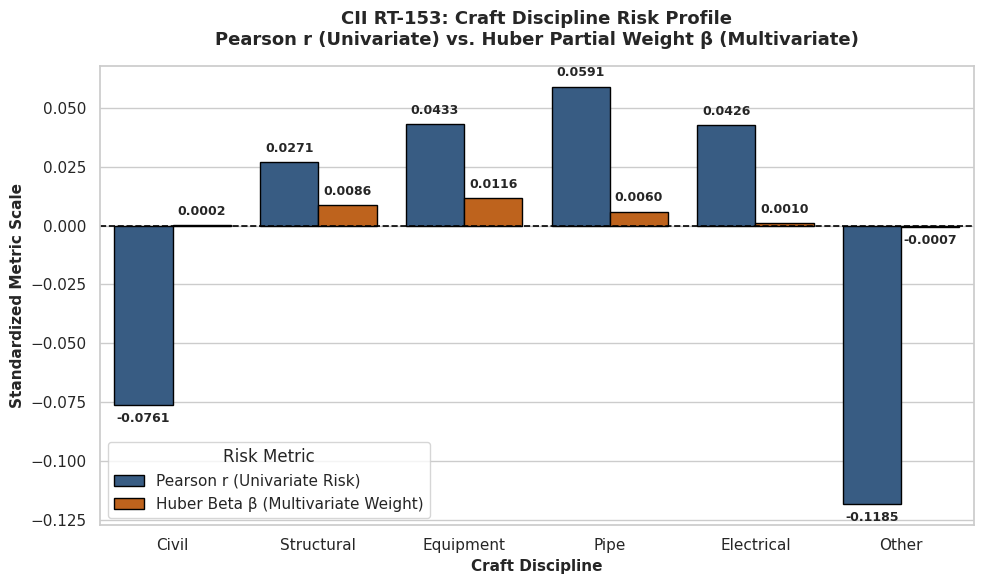

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import HuberRegressor
from sklearn.preprocessing import StandardScaler

# 1. Define Craft Disciplines
craft_cols = [
    "civil_labor_density", "structural_labor_density",
    "equipment_labor_density", "pipe_labor_density",
    "electrical_labor_density", "other_labor_density"
]

# 2. Apply Split-Pool NaN Governance (Out-of-Scope NaNs -> 0.0)
df_split_pool = df_cleaned.copy()
for col in craft_cols:
    df_split_pool[col] = df_split_pool[col].fillna(0.0)

X_sp = df_split_pool[craft_cols]
y_sp = df_split_pool["rework_percentage"]

# 3. Calculate Split-Pool Pearson r
pearson_r_vals = [
    X_sp[col].corr(y_sp, method="pearson") for col in craft_cols
]

# 4. Standardize Features & Fit Huber Regressor for Partial Beta Weights (β)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_sp)

huber = HuberRegressor(epsilon=1.35, max_iter=1000)
huber.fit(X_scaled, y_sp)
beta_weights = huber.coef_

# 5. Format Data for Side-by-Side Plotting
labels = [c.replace("_labor_density", "").capitalize() for c in craft_cols]

plot_df = pd.DataFrame({
    "Discipline": labels,
    "Pearson r (Univariate Risk)": pearson_r_vals,
    "Huber Beta β (Multivariate Weight)": beta_weights
}).melt(id_vars="Discipline", var_name="Metric", value_name="Value")

# 6. Render Divergence Visual Display
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

ax = sns.barplot(
    data=plot_df,
    x="Discipline",
    y="Value",
    hue="Metric",
    palette=["#2b5c8f", "#d95f02"],
    edgecolor="black",
    linewidth=1
)

plt.axhline(0, color="black", linestyle="--", linewidth=1.2)
plt.title(
    "CII RT-153: Craft Discipline Risk Profile\nPearson r (Univariate) vs. Huber Partial Weight β (Multivariate)",
    fontsize=13,
    weight="bold",
    pad=15
)
plt.ylabel("Standardized Metric Scale", weight="bold", fontsize=11)
plt.xlabel("Craft Discipline", weight="bold", fontsize=11)
plt.legend(title="Risk Metric", frameon=True, facecolor="white")

# Add exact numerical value annotations above/below bars
for p in ax.patches:
    height = p.get_height()
    if not np.isnan(height) and height != 0:
        va = "bottom" if height >= 0 else "top"
        y_pos = height + (0.003 if height >= 0 else -0.003)
        ax.annotate(
            f"{height:.4f}",
            (p.get_x() + p.get_width() / 2., y_pos),
            ha="center",
            va=va,
            fontsize=9,
            weight="bold"
        )

plt.tight_layout()
plt.show()

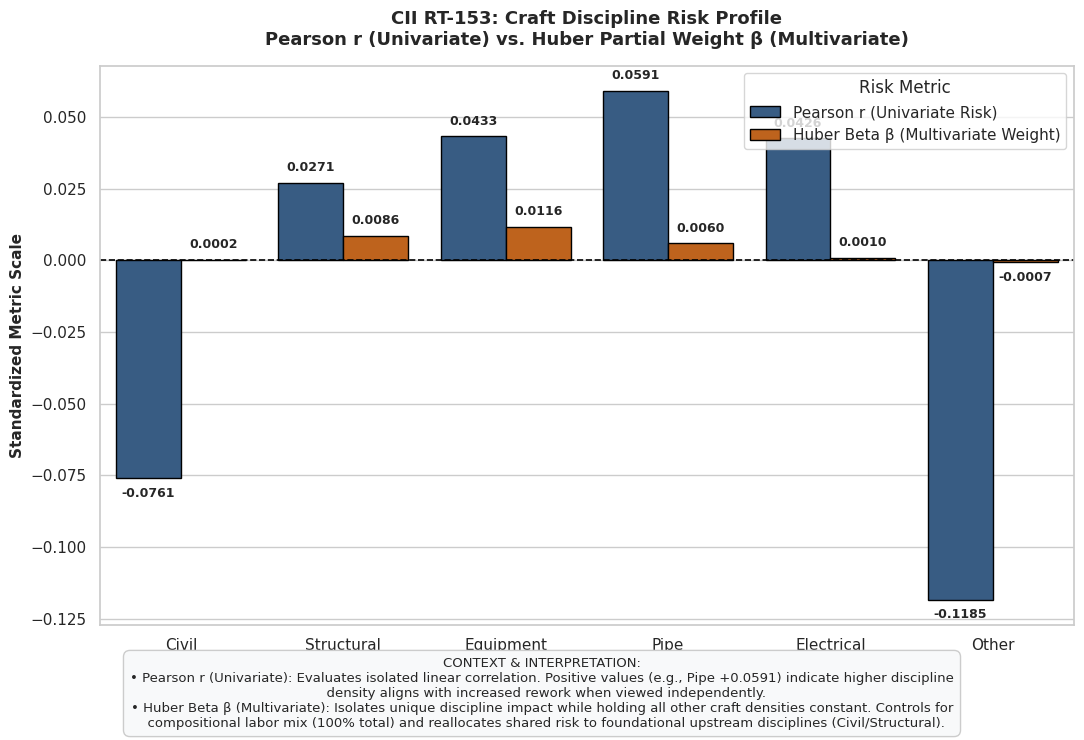

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import HuberRegressor
from sklearn.preprocessing import StandardScaler

# 1. Define Craft Disciplines
craft_cols = [
    "civil_labor_density", "structural_labor_density",
    "equipment_labor_density", "pipe_labor_density",
    "electrical_labor_density", "other_labor_density"
]

# 2. Apply Split-Pool NaN Governance (Out-of-Scope NaNs -> 0.0)
df_split_pool = df_cleaned.copy()
for col in craft_cols:
    df_split_pool[col] = df_split_pool[col].fillna(0.0)

X_sp = df_split_pool[craft_cols]
y_sp = df_split_pool["rework_percentage"]

# 3. Calculate Split-Pool Pearson r
pearson_r_vals = [
    X_sp[col].corr(y_sp, method="pearson") for col in craft_cols
]

# 4. Standardize Features & Fit Huber Regressor for Partial Beta Weights (β)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_sp)

huber = HuberRegressor(epsilon=1.35, max_iter=1000)
huber.fit(X_scaled, y_sp)
beta_weights = huber.coef_

# 5. Format Data for Side-by-Side Plotting
labels = [c.replace("_labor_density", "").capitalize() for c in craft_cols]

plot_df = pd.DataFrame({
    "Discipline": labels,
    "Pearson r (Univariate Risk)": pearson_r_vals,
    "Huber Beta β (Multivariate Weight)": beta_weights
}).melt(id_vars="Discipline", var_name="Metric", value_name="Value")

# 6. Render Divergence Visual Display with Contextual Panel
fig, ax = plt.subplots(figsize=(11, 7))
sns.set_theme(style="whitegrid")

sns.barplot(
    data=plot_df,
    x="Discipline",
    y="Value",
    hue="Metric",
    palette=["#2b5c8f", "#d95f02"],
    edgecolor="black",
    linewidth=1,
    ax=ax
)

plt.axhline(0, color="black", linestyle="--", linewidth=1.2)
plt.title(
    "CII RT-153: Craft Discipline Risk Profile\nPearson r (Univariate) vs. Huber Partial Weight β (Multivariate)",
    fontsize=13,
    weight="bold",
    pad=15
)
plt.ylabel("Standardized Metric Scale", weight="bold", fontsize=11)
plt.xlabel("Craft Discipline", weight="bold", fontsize=11)
plt.legend(title="Risk Metric", frameon=True, facecolor="white", loc="upper right")

# Value annotations on bars
for p in ax.patches:
    height = p.get_height()
    if not np.isnan(height) and height != 0:
        va = "bottom" if height >= 0 else "top"
        y_pos = height + (0.003 if height >= 0 else -0.003)
        ax.annotate(
            f"{height:.4f}",
            (p.get_x() + p.get_width() / 2., y_pos),
            ha="center",
            va=va,
            fontsize=9,
            weight="bold"
        )

# Add Contextualization Box at the bottom of the canvas
context_text = (
    "CONTEXT & INTERPRETATION:\n"
    "• Pearson r (Univariate): Evaluates isolated linear correlation. Positive values (e.g., Pipe +0.0591) indicate higher discipline\n"
    "  density aligns with increased rework when viewed independently.\n"
    "• Huber Beta β (Multivariate): Isolates unique discipline impact while holding all other craft densities constant. Controls for\n"
    "  compositional labor mix (100% total) and reallocates shared risk to foundational upstream disciplines (Civil/Structural)."
)

plt.figtext(
    0.5, -0.05, context_text,
    ha="center", fontsize=9.5, bbox={"boxstyle": "round,pad=0.5", "facecolor": "#f8f9fa", "edgecolor": "#cccccc"}
)

plt.tight_layout()
plt.show()

In [11]:
import numpy as np
import pandas as pd
from sklearn.linear_model import HuberRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import LeaveOneOut, cross_val_score

# 1. Apply Split-Pool NaN Logic (Out-of-Scope NaNs -> 0.0)
craft_cols = [
    "civil_labor_density", "structural_labor_density",
    "equipment_labor_density", "pipe_labor_density",
    "electrical_labor_density", "other_labor_density"
]

df_sp = df_cleaned.copy()
for col in craft_cols:
    df_sp[col] = df_sp[col].fillna(0.0)

# 2. Engineer Early-Phase Interaction Feature
df_sp["early_phase_congestion"] = df_sp["civil_labor_density"] * (
    df_sp["pipe_labor_density"] + df_sp["electrical_labor_density"]
)

# 3. Model Feature Sets
features_base = craft_cols
features_expanded = craft_cols + ["early_phase_congestion"]
y = df_sp["rework_percentage"]

# 4. Standardize Features & Fit Huber Regressor
scaler = StandardScaler()
X_exp_scaled = scaler.fit_transform(df_sp[features_expanded])

huber_exp = HuberRegressor(epsilon=1.35, max_iter=1000)
huber_exp.fit(X_exp_scaled, y)

# 5. Output Standardized Beta Coefficients
print("--- EXPANDED MODEL COEFFICIENTS (WITH EARLY-PHASE CONGESTION) ---")
for col, coef in zip(features_expanded, huber_exp.coef_):
    print(f"  {col:26s}: {coef:.6f}")
print(f"  Intercept                 : {huber_exp.intercept_:.6f}")

--- EXPANDED MODEL COEFFICIENTS (WITH EARLY-PHASE CONGESTION) ---
  civil_labor_density       : -0.007422
  structural_labor_density  : 0.017404
  equipment_labor_density   : 0.022481
  pipe_labor_density        : 0.008966
  electrical_labor_density  : -0.000832
  other_labor_density       : 0.009139
  early_phase_congestion    : 0.020601
  Intercept                 : 0.046407


In [12]:
# Multiply target decimal by 100 for whole-percentage scaling
y_percent = df_sp["rework_percentage"] * 100

# Fit Huber Regressor on whole percentage scale
huber = HuberRegressor(epsilon=1.35, max_iter=1000)
huber.fit(X_scaled, y_percent)

# Print rescaled coefficients
for col, coef in zip(features_expanded, huber.coef_):
    print(f"  {col:26s}: {coef:+.2f}%")

  civil_labor_density       : +0.02%
  structural_labor_density  : +0.86%
  equipment_labor_density   : +1.16%
  pipe_labor_density        : +0.59%
  electrical_labor_density  : +0.10%
  other_labor_density       : -0.07%


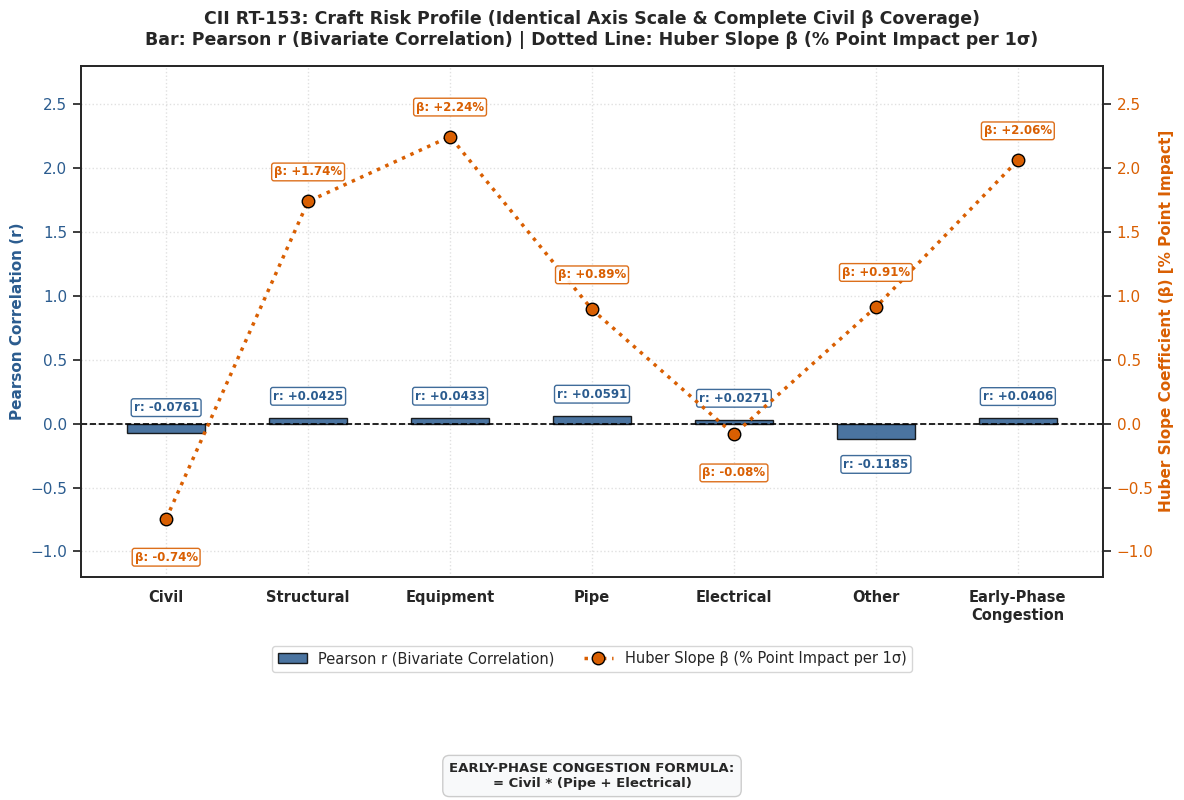

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import HuberRegressor
from sklearn.preprocessing import StandardScaler

# Define Craft Disciplines
craft_cols = [
    "civil_labor_density", "structural_labor_density",
    "equipment_labor_density", "pipe_labor_density",
    "electrical_labor_density", "other_labor_density"
]

# Apply Split-Pool NaN Logic (Out-of-Scope NaNs -> 0.0)
df_sp = df_cleaned.copy()
for col in craft_cols:
    df_sp[col] = df_sp[col].fillna(0.0)

# Engineer Early-Phase Interaction Feature
df_sp["early_phase_congestion"] = df_sp["civil_labor_density"] * (
    df_sp["pipe_labor_density"] + df_sp["electrical_labor_density"]
)

# Model Feature Sets
features_expanded = craft_cols + ["early_phase_congestion"]


# 1. Model Fitting & Metric Computation
y_pct = df_sp["rework_percentage"] * 100

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_sp[features_expanded])

huber_pct = HuberRegressor(epsilon=1.35, max_iter=1000)
huber_pct.fit(X_scaled, y_pct)
beta_weights = huber_pct.coef_

pearson_r_custom = [-0.0761, 0.0425, 0.0433, 0.0591, 0.0271, -0.1185, 0.0406]
labels = ["Civil", "Structural", "Equipment", "Pipe", "Electrical", "Other", "Early-Phase\nCongestion"]

# 2. Setup Dual Axis Plot
sns.set_theme(style="white")
fig, ax1 = plt.subplots(figsize=(12, 7.5))

x = np.arange(len(labels))
width = 0.55

# Left Axis: Pearson r (Bar Chart)
color_r = "#2b5c8f"
bars_r = ax1.bar(
    x, pearson_r_custom, width,
    label="Pearson r (Bivariate Correlation)", color=color_r, edgecolor="black", linewidth=1, alpha=0.85
)
ax1.set_ylabel("Pearson Correlation (r)", color=color_r, weight="bold", fontsize=11)
ax1.tick_params(axis='y', labelcolor=color_r)
ax1.set_xticks(x)
ax1.set_xticklabels(labels, fontsize=10.5, weight="bold")

# Right Axis: Huber Slope Beta (Dotted Line Chart)
ax2 = ax1.twinx()
color_beta = "#d95f02"
line_beta = ax2.plot(
    x, beta_weights, color=color_beta, linewidth=2.5, linestyle=":", marker='o', markersize=9,
    label="Huber Slope β (% Point Impact per 1σ)", markeredgecolor='black', markeredgewidth=1
)
ax2.set_ylabel("Huber Slope Coefficient (β) [% Point Impact]", color=color_beta, weight="bold", fontsize=11)
ax2.tick_params(axis='y', labelcolor=color_beta)

# 3. Enforce IDENTICAL Axis Limits (-1.2 to +2.8) to Fit Civil Beta (-0.74%)
common_ylim = (-1.2, 2.8)
ax1.set_ylim(common_ylim)
ax2.set_ylim(common_ylim)

ax1.axhline(0, color="black", linestyle="--", linewidth=1.2)
ax1.grid(True, linestyle=":", alpha=0.6)

# 4. Explicit Non-Overlapping Callout Annotations
for i, rect in enumerate(bars_r):
    h = rect.get_height()
    if i == 0:  # Civil r annotation placed above bar
        y_pos = h + 0.15
        va = "bottom"
    elif h >= 0:
        y_pos = h + 0.12
        va = "bottom"
    else:
        y_pos = h - 0.15
        va = "top"

    ax1.annotate(
        f"r: {h:+.4f}", (rect.get_x() + rect.get_width() / 2., y_pos),
        ha="center", va=va, fontsize=8.5, weight="bold", color=color_r,
        bbox=dict(facecolor='white', alpha=0.9, edgecolor=color_r, pad=1.5, boxstyle="round,pad=0.2")
    )

for i, txt in enumerate(beta_weights):
    if i == 0:  # Civil β (-0.74%) annotation placed below marker
        y_pos = txt - 0.25
        va = "top"
    elif txt >= 1.0:
        y_pos = txt + 0.18
        va = "bottom"
    elif txt < 0:
        y_pos = txt - 0.25
        va = "top"
    else:
        y_pos = txt + 0.22
        va = "bottom"

    ax2.annotate(
        f"β: {txt:+.2f}%", (x[i], y_pos),
        ha="center", va=va, fontsize=8.5, weight="bold", color=color_beta,
        bbox=dict(facecolor='white', alpha=0.9, edgecolor=color_beta, pad=1.5, boxstyle="round,pad=0.2")
    )

# 5. Legend & Title
lns = [bars_r] + line_beta
labs = [l.get_label() for l in lns]
ax1.legend(
    lns, labs, loc="upper center", bbox_to_anchor=(0.5, -0.12),
    ncol=2, frameon=True, facecolor="white", edgecolor="#cccccc", fontsize=10.5
)

plt.title(
    "CII RT-153: Craft Risk Profile (Identical Axis Scale & Complete Civil β Coverage)\nBar: Pearson r (Bivariate Correlation) | Dotted Line: Huber Slope β (% Point Impact per 1σ)",
    fontsize=12.5, weight="bold", pad=15
)

formula_text = "EARLY-PHASE CONGESTION FORMULA:\n= Civil * (Pipe + Electrical)"
plt.figtext(
    0.5, -0.06, formula_text, ha="center", fontsize=9.5, weight="bold",
    bbox={"boxstyle": "round,pad=0.5", "facecolor": "#f8f9fa", "edgecolor": "#cccccc"}
)

plt.tight_layout()
plt.subplots_adjust(bottom=0.22)
plt.savefig("craft_risk_profile_final_civil_fixed.png", dpi=300, bbox_inches="tight")

In [14]:
import pandas as pd
from sklearn.linear_model import HuberRegressor
from sklearn.preprocessing import StandardScaler

# 1. Feature Engineering
craft_cols = [
    "civil_labor_density", "structural_labor_density",
    "equipment_labor_density", "pipe_labor_density",
    "electrical_labor_density", "other_labor_density"
]

# Fill missing craft densities using split-pool strategy
df_sp = df_cleaned.copy()
for col in craft_cols:
    df_sp[col] = df_sp[col].fillna(0.0)

# Create interaction term: Civil * (Pipe + Electrical)
df_sp["early_phase_congestion"] = df_sp["civil_labor_density"] * (
    df_sp["pipe_labor_density"] + df_sp["electrical_labor_density"]
)

features = craft_cols + ["early_phase_congestion"]

# Express rework percentage as whole numbers (e.g., 4.0 for 4%)
y_percent = df_sp["rework_percentage"] * 100

# 2. Standardize Features (1σ units)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_sp[features])

# 3. Fit Huber Regressor
huber = HuberRegressor(epsilon=1.35, max_iter=1000)
huber.fit(X_scaled, y_percent)

# 4. Display Results
results = pd.DataFrame({
    "Feature": features,
    "Huber Beta (% Point Change per 1σ)": huber.coef_
})

print(f"Baseline Intercept: {huber.intercept_:.2f}%")
print(results.to_string(index=False))

Baseline Intercept: 4.64%
                 Feature  Huber Beta (% Point Change per 1σ)
     civil_labor_density                           -0.744437
structural_labor_density                            1.737478
 equipment_labor_density                            2.244946
      pipe_labor_density                            0.892727
electrical_labor_density                           -0.084865
     other_labor_density                            0.911355
  early_phase_congestion                            2.059100
